<a href="https://colab.research.google.com/github/Totor-Le-Taureau/Victor_Lory_Roch_Behaghel/blob/main/Track_E_Victor_Roch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background:linear-gradient(135deg, #0a1628, #0c3547); border-radius:16px; padding:36px 40px; color:white; font-family:system-ui,sans-serif;"><div style="font-size:11px; letter-spacing:3px; opacity:0.5; margin-bottom:12px;">MODULE 1 - MACHINE LISTENING - TRACK E - SOLUTION COMPLETE</div><div style="font-size:32px; font-weight:800; line-height:1.2; margin-bottom:12px;">Surveillance de la Biodiversite Aviaire</div><div style="font-size:15px; opacity:0.75; max-width:620px; line-height:1.6; margin-bottom:20px;">Identifier 21 especes d'oiseaux par leur chant — BirdSet HSN · Classification multi-label · AST fine-tuning · Interface Gradio</div><div style="display:flex; gap:10px; flex-wrap:wrap;"><span style="background:rgba(255,255,255,0.1); padding:5px 14px; border-radius:20px; font-size:12px;">BirdSet HSN · 21 especes</span><span style="background:rgba(255,255,255,0.1); padding:5px 14px; border-radius:20px; font-size:12px;">Multi-label · BCE Loss</span><span style="background:rgba(255,255,255,0.1); padding:5px 14px; border-radius:20px; font-size:12px;">Transfer Learning AST</span><span style="background:rgba(255,255,255,0.1); padding:5px 14px; border-radius:20px; font-size:12px;">SpecAugment</span><span style="background:rgba(255,255,255,0.1); padding:5px 14px; border-radius:20px; font-size:12px;">Gradio Interface</span></div></div>

In [20]:
# ============================================================
# INSTALLATION — une seule fois
# datasets<4 requis pour BirdSet (script custom HuggingFace)
# ============================================================
!pip install "datasets<4" librosa transformers evaluate accelerate torchaudio gradio scikit-learn seaborn -q

import torch, torchaudio, librosa, librosa.display
import numpy as np, matplotlib.pyplot as plt
import pandas as pd, seaborn as sns
import IPython.display as ipd
from IPython.display import HTML, display
from collections import Counter

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch {torch.__version__} | Device : {device}")
print(f"librosa {librosa.__version__}")

SR = 32000        # BirdSet = 32 kHz (oiseaux chantent jusqu a 15 kHz)
DURATION = 5      # Segments de 5 secondes
N_SAMPLES = SR * DURATION   # 160 000 samples
N_CLASSES = 21    # 21 especes dans HSN
print(f"Constantes : SR={SR}Hz | Duree={DURATION}s | N_SAMPLES={N_SAMPLES} | N_CLASSES={N_CLASSES}")


PyTorch 2.10.0+cu128 | Device : cuda
librosa 0.11.0
Constantes : SR=32000Hz | Duree=5s | N_SAMPLES=160000 | N_CLASSES=21


In [21]:
# ============================================================
# ETAPE 1a : CHARGER LE DATASET BIRDSET HSN
# ============================================================
# BirdSet (Rauch et al., 2024) : benchmark bioacoustique aviaire
# HSN = High Sierra Nevada : 5460 enregistrements, 21 especes
# MULTI-LABEL : plusieurs oiseaux peuvent chanter simultanement

from datasets import load_dataset

try:
    dataset = load_dataset("DBD-research-group/BirdSet", "HSN", trust_remote_code=True)
    print("Dataset charge depuis HuggingFace Hub")
except Exception as e:
    print(f"HuggingFace echoue ({type(e).__name__}). Essai chargement local...")
    try:
        from datasets import load_from_disk
        dataset = load_from_disk("/content/drive/MyDrive/birdset_hsn")
        print("Dataset charge depuis Google Drive")
    except:
        print("Chargement impossible. Verifiez avec l'enseignant.")
        raise

train_data = dataset["train"]
print(f"Splits : {list(dataset.keys())}")
print(f"Colonnes : {train_data.column_names}")
print(f"Train : {len(train_data)} enregistrements")
if "test_5s" in dataset:
    print(f"Test  : {len(dataset['test_5s'])} enregistrements")

# Mapping especes
SPECIES = sorted(set(train_data["ebird_code"]))
LABEL2ID = {sp: i for i, sp in enumerate(SPECIES)}
ID2LABEL = {i: sp for sp, i in LABEL2ID.items()}
print(f"\n{len(SPECIES)} especes : {SPECIES}")


Dataset charge depuis HuggingFace Hub
Splits : ['train', 'test', 'test_5s']
Colonnes : ['audio', 'filepath', 'start_time', 'end_time', 'low_freq', 'high_freq', 'ebird_code', 'ebird_code_multilabel', 'ebird_code_secondary', 'call_type', 'sex', 'lat', 'long', 'length', 'microphone', 'license', 'source', 'local_time', 'detected_events', 'event_cluster', 'peaks', 'quality', 'recordist', 'genus', 'species_group', 'order', 'genus_multilabel', 'species_group_multilabel', 'order_multilabel']
Train : 5460 enregistrements
Test  : 12000 enregistrements

21 especes : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]


In [22]:
# ============================================================
# ETAPE 1b : ECOUTER 5 CHANTS D OISEAUX DIFFERENTS (FINAL FIX)
# ============================================================

import numpy as np
import IPython.display as ipd
import soundfile as sf

print("ECOUTE DE 5 ESPECES")
print("="*50)

species_seen = set()

for clip in train_data:
    sp = clip["ebird_code"]

    if sp in species_seen:
        continue

    if len(species_seen) >= 5:
        break

    species_seen.add(sp)

    # lecture audio
    audio_path = clip["audio"]["path"]
    audio, sr_clip = sf.read(audio_path)

    # convertir en numpy float32
    audio = np.array(audio, dtype=np.float32)

    # si stéréo → mono
    if len(audio.shape) > 1:
        audio = np.mean(audio, axis=1)

    # normalisation (évite bug IPython)
    if np.max(np.abs(audio)) > 0:
        audio = audio / np.max(np.abs(audio))

    labels = clip.get("ebird_code_multilabel", [sp])

    print(f"\n{sp} — {len(audio)/sr_clip:.1f}s — {sr_clip} Hz")
    print(f"   Labels presents : {labels}")

    # limite à 5 secondes
    display(ipd.Audio(audio[:sr_clip*5], rate=int(sr_clip)))

ECOUTE DE 5 ESPECES

11 — 20.1s — 32000 Hz
   Labels presents : [11]



19 — 66.6s — 32000 Hz
   Labels presents : [19]



20 — 17.9s — 32000 Hz
   Labels presents : [20]



3 — 63.9s — 32000 Hz
   Labels presents : [3]



16 — 10.2s — 32000 Hz
   Labels presents : [16]


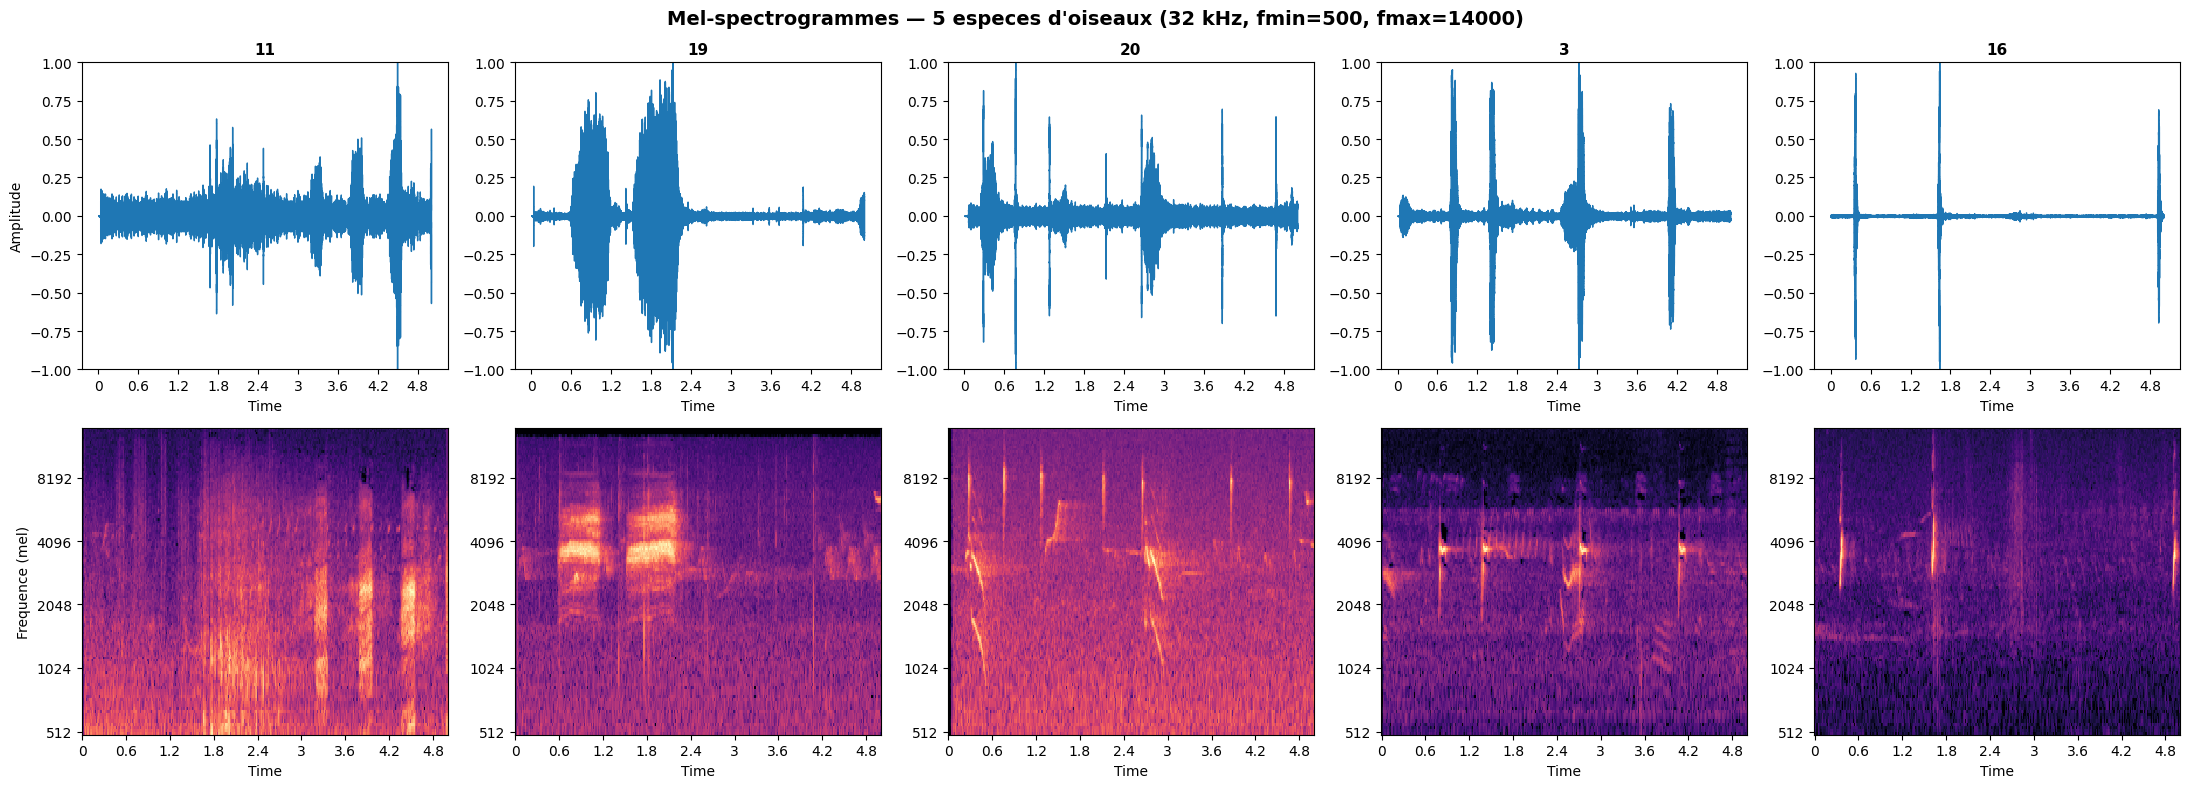

Observations :
  - Trilles rapides  → series de points repetes
  - Sifflements      → lignes diagonales lisses
  - Chants melodiques → motifs structures complexes


In [23]:
# ============================================================
# ETAPE 1c : SPECTROGRAMMES DE 5 ESPECES (SAFE VERSION)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import soundfile as sf

# paramètres globaux (au cas où)
SR = 32000
N_SAMPLES = SR * 5  # 5 secondes

# ============================================================
# 🔥 On récupère 5 espèces SANS filter()
# ============================================================

selected_clips = []
species_seen = set()

for clip in train_data:
    sp = clip["ebird_code"]

    if sp in species_seen:
        continue

    species_seen.add(sp)
    selected_clips.append(clip)

    if len(selected_clips) >= 5:
        break

# ============================================================
# fonctions audio robustes
# ============================================================

def load_and_pad_audio(sample, target_sr=SR, target_len=N_SAMPLES):
    audio_path = sample["audio"]["path"]
    audio, sr_orig = sf.read(audio_path)

    audio = np.array(audio, dtype=np.float32)

    # mono
    if len(audio.shape) > 1:
        audio = np.mean(audio, axis=1)

    # resample
    if sr_orig != target_sr:
        audio = librosa.resample(audio, orig_sr=sr_orig, target_sr=target_sr)

    # pad / cut
    if len(audio) > target_len:
        audio = audio[:target_len]
    elif len(audio) < target_len:
        audio = np.pad(audio, (0, target_len - len(audio)))

    # normalisation
    if np.max(np.abs(audio)) > 0:
        audio = audio / np.max(np.abs(audio))

    return audio


def compute_mel_birds(audio, sr=SR, n_mels=128, fmin=500, fmax=14000):
    S = librosa.feature.melspectrogram(
        y=audio,
        sr=sr,
        n_fft=1024,
        hop_length=512,
        n_mels=n_mels,
        fmin=fmin,
        fmax=fmax
    )
    return librosa.power_to_db(S, ref=np.max)

# ============================================================
# affichage
# ============================================================

fig, axes = plt.subplots(2, 5, figsize=(22, 8))

fig.suptitle(
    "Mel-spectrogrammes — 5 especes d'oiseaux (32 kHz, fmin=500, fmax=14000)",
    fontsize=14,
    fontweight="bold"
)

for i, clip in enumerate(selected_clips):
    sp = clip["ebird_code"]

    audio = load_and_pad_audio(clip)

    # waveform
    librosa.display.waveshow(audio, sr=SR, ax=axes[0, i])
    axes[0, i].set_title(sp, fontsize=11, fontweight="bold")
    axes[0, i].set_ylim(-1, 1)

    # spectrogram
    mel = compute_mel_birds(audio)

    librosa.display.specshow(
        mel,
        sr=SR,
        hop_length=512,
        fmin=500,
        fmax=14000,
        x_axis="time",
        y_axis="mel",
        ax=axes[1, i],
        cmap="magma"
    )
    axes[1, i].set_ylabel("")

axes[0, 0].set_ylabel("Amplitude")
axes[1, 0].set_ylabel("Frequence (mel)")

plt.tight_layout()
plt.show()

print("Observations :")
print("  - Trilles rapides  → series de points repetes")
print("  - Sifflements      → lignes diagonales lisses")
print("  - Chants melodiques → motifs structures complexes")

In [24]:
# ============================================================
# ETAPE 1d : COMPRENDRE LE MULTI-LABEL
# ============================================================
# Multi-classe (ESC-50 demo) : un seul label = entier unique
# Multi-label  (ici)         : plusieurs labels = vecteur binaire de 21 dimensions
#
# Cette difference entraine une CASCADE :
#   label    : int         -> FloatTensor(21)
#   loss     : CrossEntropy -> BCEWithLogitsLoss
#   output   : softmax      -> sigmoid
#   decision : argmax       -> (probs > seuil)
#   metrique : accuracy     -> F1 macro

print("=== 5 EXEMPLES MULTI-LABEL ===")
for i in range(5):
    sample = train_data[i]
    labels = sample.get("ebird_code_multilabel", [sample["ebird_code"]])
    print(f"  Clip {i} : {len(labels)} espece(s) -> {labels}")

# Distribution
label_counts = []
for i in range(min(500, len(train_data))):
    labels = train_data[i].get("ebird_code_multilabel", [train_data[i]["ebird_code"]])
    label_counts.append(len(labels))
label_counts = np.array(label_counts)

print(f"\nDistribution (sur {len(label_counts)} clips) :")
print(f"  1 espece  : {(label_counts==1).sum()} ({(label_counts==1).mean()*100:.1f}%)")
print(f"  2 especes : {(label_counts==2).sum()} ({(label_counts==2).mean()*100:.1f}%)")
print(f"  3+        : {(label_counts>=3).sum()} ({(label_counts>=3).mean()*100:.1f}%)")
print(f"  Moyenne   : {label_counts.mean():.2f} labels/clip")

# Exemple vecteur multi-hot
example_sp = SPECIES[:2]
multi_hot = np.zeros(N_CLASSES)
for sp in example_sp:
    multi_hot[LABEL2ID[sp]] = 1
print(f"\nExemple multi-hot pour {example_sp} :")
print(f"  {multi_hot.astype(int)}")
print("  -> Vecteur de 21 zeros avec 1 aux positions des especes presentes")


=== 5 EXEMPLES MULTI-LABEL ===
  Clip 0 : 1 espece(s) -> [11]
  Clip 1 : 1 espece(s) -> [11]
  Clip 2 : 1 espece(s) -> [11]
  Clip 3 : 1 espece(s) -> [11]
  Clip 4 : 1 espece(s) -> [11]

Distribution (sur 500 clips) :
  1 espece  : 500 (100.0%)
  2 especes : 0 (0.0%)
  3+        : 0 (0.0%)
  Moyenne   : 1.00 labels/clip

Exemple multi-hot pour [0, 1] :
  [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
  -> Vecteur de 21 zeros avec 1 aux positions des especes presentes


In [25]:
# REPONSE — Questions rouges Etape 1

# (1) Spectrogrammes d'oiseaux plus structures ?
# OUI. Notes bien definies en frequence (trilles, sifflements, sequences melodiques).
# Sons urbains (klaxon, pluie) = spectre large bande, moins organise.

# (2) Oiseaux avec chants similaires ?
# En ecoutant : certains bruants (sparrows) ont des trilles proches.
# Les gobe-mouches et mesanges partagent des structures similaires.
# -> Regardez la matrice de confusion (Etape 7) pour confirmation.

# (3) F1 macro vs accuracy en multi-label ?
# accuracy_score = TROP SEVERE : doit predire EXACTEMENT le vecteur entier.
# F1 macro : calcule F1 par classe independamment puis fait la moyenne.
# -> Penalise equitablement les erreurs sur especes rares ET communes.
# -> Metrique adaptee au desequilibre de classes.

# (4) Micro autonome en foret — contraintes ?
# - Batterie : limitee -> inference legere ou declenchement par activite sonore
# - Meteo : pluie, vent -> bruit de fond variable dans le spectrogramme
# - Memoire : stocker predictions ou transmettre par radio basse consommation
# - Temperature : -20C a +50C pour les composants electroniques
# - Faux positifs : le vent peut ressembler a des chants

print("Reflexion Etape 1 OK")


Reflexion Etape 1 OK


In [26]:
# CHECKPOINT — Etape 1
from IPython.display import HTML, display
display(HTML('<div style="border-left:4px solid #1e7e34;background:#e8f5e9;border-radius:0 8px 8px 0;padding:14px 20px;font-family:system-ui,sans-serif;"><b style="color:#1e7e34;">Etape 1 validee OK</b> <span style="color:#1e5631;">BirdSet HSN explore. 21 especes ecoutees. Multi-label compris.</span></div>'))

In [27]:
# ============================================================
# ETAPE 2a : PIPELINE ADAPTE AUX OISEAUX
# ============================================================
# DIFFERENCES vs pipeline ESC-50 de la demo :
#   Demo ESC-50 : 44.1kHz->16kHz | fmin=0     | fmax=8000
#   BirdSet     : 32kHz NATIF    | fmin=500   | fmax=14000
#
# POURQUOI fmin=500, fmax=14000 ?
#   fmin=500 Hz : elimine vent, trafic, grondements basses frequences
#   fmax=14000 Hz : capture les aigus des chants d'oiseaux
#
# POURQUOI GARDER 32 kHz ?
#   Theoreme de Nyquist : pour capturer fmax=14000 Hz, SR >= 28000 Hz
#   Avec SR=16kHz : fmax capturee = 8kHz -> on PERD les aigus !

# Fonctions definies en Etape 1c (load_and_pad_audio, compute_mel_birds)
# Les reutiliser ici.

# Tester sur 1 clip
clip = train_data[0]
audio = load_and_pad_audio(clip)
print(f"Audio charge : {len(audio)} samples = {len(audio)/SR:.1f}s @ {SR}Hz")

# Comparer generique vs oiseaux
mel_birds   = compute_mel_birds(audio, fmin=500, fmax=14000)
mel_generic = librosa.power_to_db(
    librosa.feature.melspectrogram(y=audio, sr=SR, n_mels=128),
    ref=np.max)

print(f"Mel birds   : shape {mel_birds.shape}   (fmin=500, fmax=14000)")
print(f"Mel generique: shape {mel_generic.shape} (fmin=0,   fmax=16000)")


Audio charge : 160000 samples = 5.0s @ 32000Hz
Mel birds   : shape (128, 313)   (fmin=500, fmax=14000)
Mel generique: shape (128, 313) (fmin=0,   fmax=16000)


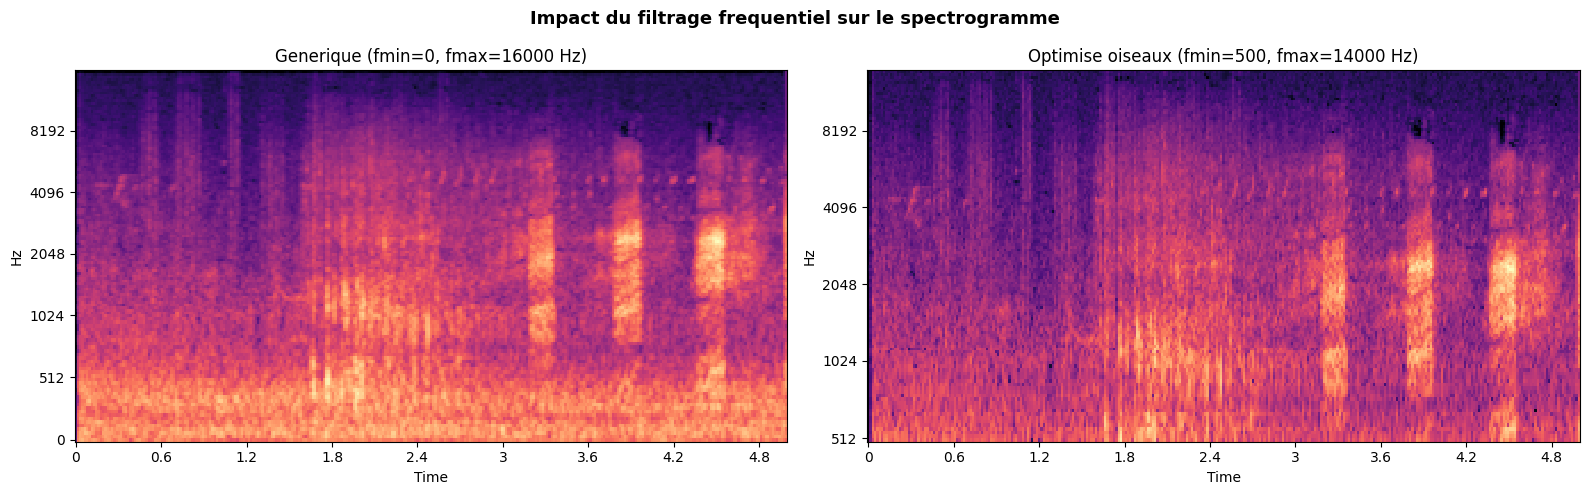

Le spectrogramme optimise :
  - Elimine le bruit basse frequence (vent, trafic) sous 500 Hz
  - Conserve les hautes frequences riches des chants
  - Meilleur contraste visuel sur les structures melodiques


In [28]:
# ============================================================
# ETAPE 2b : VISUALISER L'IMPACT DU FILTRAGE FREQUENTIEL
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Impact du filtrage frequentiel sur le spectrogramme", fontsize=13, fontweight="bold")

librosa.display.specshow(mel_generic, sr=SR, hop_length=512,
                         x_axis="time", y_axis="mel", ax=axes[0], cmap="magma")
axes[0].set_title("Generique (fmin=0, fmax=16000 Hz)")

librosa.display.specshow(mel_birds, sr=SR, hop_length=512,
                         fmin=500, fmax=14000,
                         x_axis="time", y_axis="mel", ax=axes[1], cmap="magma")
axes[1].set_title("Optimise oiseaux (fmin=500, fmax=14000 Hz)")

plt.tight_layout()
plt.show()

print("Le spectrogramme optimise :")
print("  - Elimine le bruit basse frequence (vent, trafic) sous 500 Hz")
print("  - Conserve les hautes frequences riches des chants")
print("  - Meilleur contraste visuel sur les structures melodiques")


In [29]:
# ============================================================
# ETAPE 2c : COHERENCE DU PIPELINE SUR 5 CLIPS (FIXED)
# ============================================================

import soundfile as sf
import numpy as np

print("Test de coherence du pipeline sur 5 clips :")
print("="*60)

for i in range(5):
    sample = train_data[i]

    # ✅ lecture brute depuis fichier
    audio_path = sample["audio"]["path"]
    audio_raw, sr_raw = sf.read(audio_path)
    audio_raw = np.array(audio_raw, dtype=np.float32)

    # mono si besoin
    if len(audio_raw.shape) > 1:
        audio_raw = np.mean(audio_raw, axis=1)

    # pipeline
    audio = load_and_pad_audio(sample)
    mel = compute_mel_birds(audio)

    dur_raw = len(audio_raw) / sr_raw

    print(f"  Clip {i}: raw={dur_raw:.1f}s -> {len(audio)} samples | mel shape: {mel.shape}")

print("\nToutes les shapes identiques -> pipeline coherent !")

Test de coherence du pipeline sur 5 clips :
  Clip 0: raw=20.1s -> 160000 samples | mel shape: (128, 313)
  Clip 1: raw=37.8s -> 160000 samples | mel shape: (128, 313)
  Clip 2: raw=10.0s -> 160000 samples | mel shape: (128, 313)
  Clip 3: raw=6.4s -> 160000 samples | mel shape: (128, 313)
  Clip 4: raw=6.1s -> 160000 samples | mel shape: (128, 313)

Toutes les shapes identiques -> pipeline coherent !


In [30]:
# REPONSE — Questions rouges Etape 2

# (1) Pourquoi 32 kHz ?
# Les oiseaux chantent jusqu'a 15 kHz. Theoreme de Nyquist : SR >= 2 x fmax.
# Avec SR=16kHz -> fmax = 8kHz -> perte de TOUTES les frequences 8-15kHz.
# Exemple : certaines fauvettes chantent a 10-12 kHz -> inaudibles a 16kHz.

# (2) Especes qui chantent < 500 Hz ?
# OUI : certains rapaces nocturnes (grands-ducs) ont des appels a 300-500 Hz.
# Compromis acceptable : HSN Sierra Nevada n'a pas ces especes dans ses 21 classes.
# A verifier cas par cas avant de choisir fmin.

# (3) Reechantillonnage 32kHz->16kHz pour l'AST ?
# OUI : on perd l'information 8-16kHz.
# Attenuation possible :
#   - Utiliser un modele pre-entraine a 32kHz si disponible (PANNs)
#   - Calculer features avant resampling puis passer features a l'AST
#   - Accepter la perte pour beneficier du transfer learning AudioSet

print("Reflexion Etape 2 OK")


Reflexion Etape 2 OK


In [31]:
# CHECKPOINT — Etape 2
from IPython.display import HTML, display
display(HTML('<div style="border-left:4px solid #1e7e34;background:#e8f5e9;border-radius:0 8px 8px 0;padding:14px 20px;font-family:system-ui,sans-serif;"><b style="color:#1e7e34;">Etape 2 validee OK</b> <span style="color:#1e5631;">Pipeline 32kHz avec fmin=500/fmax=14000 optimise. Comparaison generique vs oiseaux effectuee.</span></div>'))

In [32]:
# ============================================================
# ETAPE 3a : EXTRAIRE LES MFCC (VERSION RAPIDE)
# ============================================================

from collections import Counter
import numpy as np
import librosa

print("Extraction des MFCC ...")

N_MFCC = 13

# paramètres pour accélérer
MAX_PER_SPECIES = 50   # limite par espèce
MAX_TOTAL = 1000       # limite globale

X, y = [], []
clips_per_species = {}
total = 0

for sample in train_data:

    # stop rapide
    if total >= MAX_TOTAL:
        break

    sp = sample["ebird_code"]

    # limite par espèce
    if clips_per_species.get(sp, 0) >= MAX_PER_SPECIES:
        continue

    clips_per_species[sp] = clips_per_species.get(sp, 0) + 1
    total += 1

    # pipeline audio (déjà robuste)
    audio = load_and_pad_audio(sample)

    # MFCC
    mfcc = librosa.feature.mfcc(y=audio, sr=SR, n_mfcc=N_MFCC)

    # features : moyenne + std
    features = np.concatenate([
        mfcc.mean(axis=1),
        mfcc.std(axis=1)
    ])

    X.append(features)
    y.append(sp)

# conversion numpy
X = np.array(X)
y = np.array(y)

print(f"Features : {X.shape[0]} clips x {X.shape[1]} features")
print(f"Distribution top 3 : {Counter(y).most_common(3)}")

Extraction des MFCC ...
Features : 1000 clips x 26 features
Distribution top 3 : [(np.int64(11), 50), (np.int64(19), 50), (np.int64(20), 50)]


In [33]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# ============================================================
# ETAPE 3b : COMPARER 3 CLASSIFIEURS
# ============================================================

le = LabelEncoder()
y_enc = le.fit_transform(y)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc)
print(f"Train : {len(X_train)} clips | Test : {len(X_test)} clips")

results = {}

print("Random Forest...")
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
results["Random Forest"] = {
    "accuracy": accuracy_score(y_test, y_pred_rf),
    "f1_macro": f1_score(y_test, y_pred_rf, average="macro", zero_division=0)
}

print("SVM RBF...")
scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_train)
X_te_sc = scaler.transform(X_test)
svm = SVC(kernel="rbf", C=10, gamma="scale", random_state=42)
svm.fit(X_tr_sc, y_train)
y_pred_svm = svm.predict(X_te_sc)
results["SVM RBF"] = {
    "accuracy": accuracy_score(y_test, y_pred_svm),
    "f1_macro": f1_score(y_test, y_pred_svm, average="macro", zero_division=0)
}

print("Gradient Boosting...")
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
results["Gradient Boosting"] = {
    "accuracy": accuracy_score(y_test, y_pred_gb),
    "f1_macro": f1_score(y_test, y_pred_gb, average="macro", zero_division=0)
}

print("\n" + "="*55)
print(f"{'Modele':<22} | {'Accuracy':>10} | {'F1 Macro':>10}")
print("="*55)
for name, scores in results.items():
    print(f"{name:<22} | {scores['accuracy']:>10.4f} | {scores['f1_macro']:>10.4f}")
print("="*55)

best_baseline = max(results, key=lambda k: results[k]["f1_macro"])
baseline_f1 = results[best_baseline]["f1_macro"]
print(f"\nMeilleur baseline : {best_baseline} (F1={baseline_f1:.4f})")

Train : 800 clips | Test : 200 clips
Random Forest...
SVM RBF...
Gradient Boosting...

Modele                 |   Accuracy |   F1 Macro
Random Forest          |     0.3450 |     0.3369
SVM RBF                |     0.4100 |     0.3879
Gradient Boosting      |     0.2850 |     0.2711

Meilleur baseline : SVM RBF (F1=0.3879)


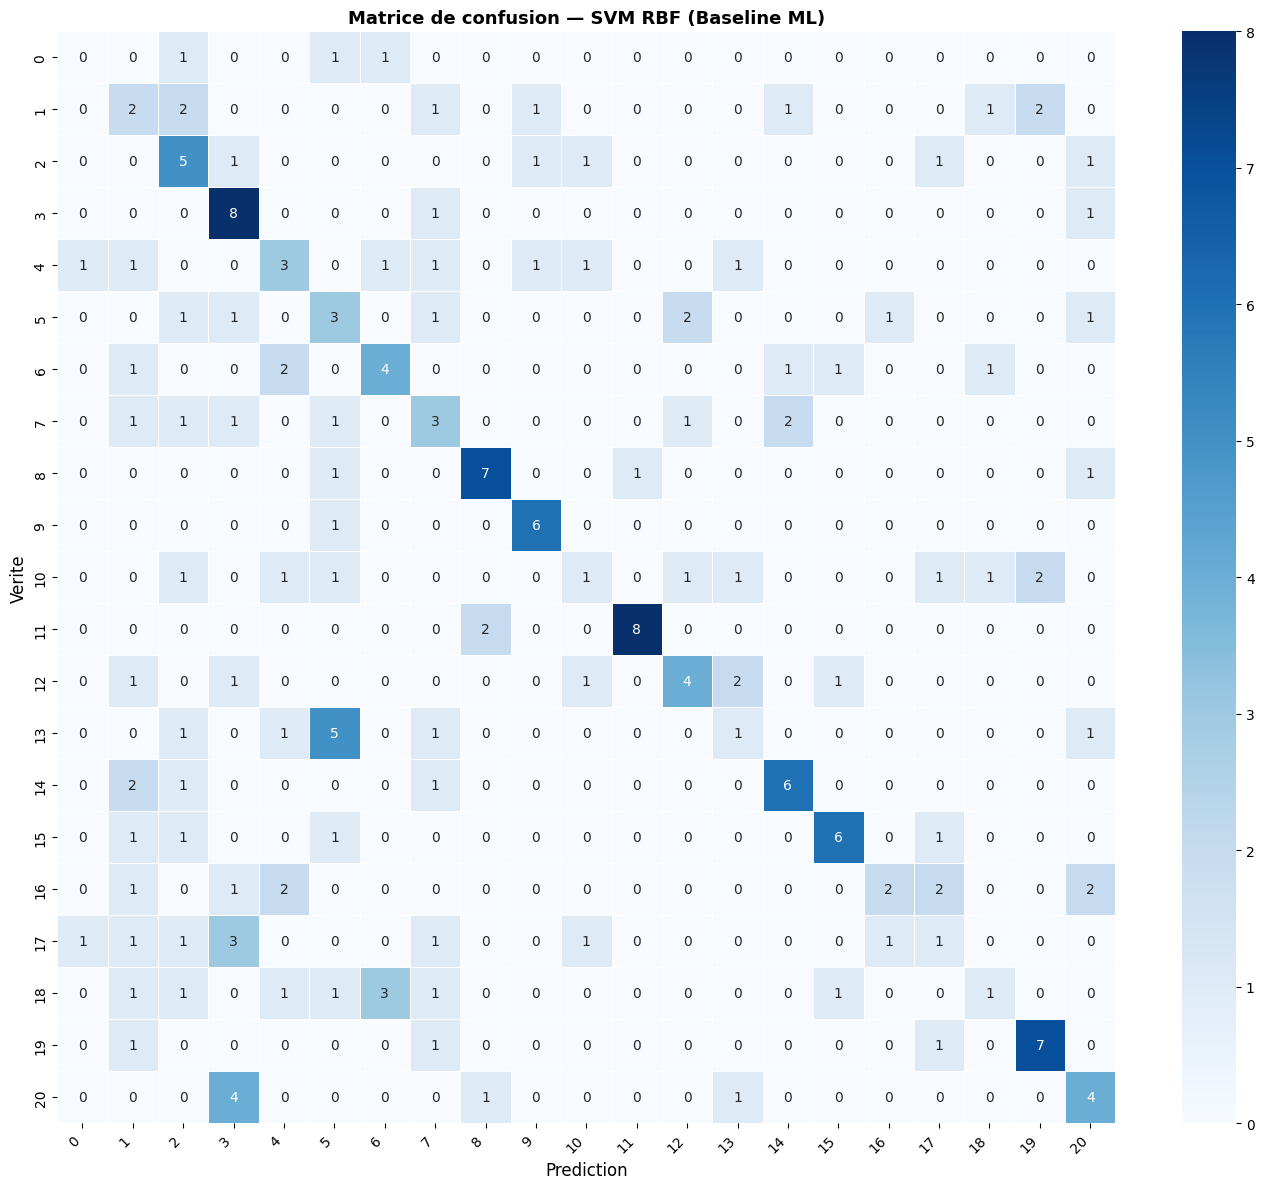

Top 5 confusions :
  13 -> 5 : 5 fois
  20 -> 3 : 4 fois
  18 -> 6 : 3 fois
  17 -> 3 : 3 fois
  16 -> 20 : 2 fois


In [34]:
# ============================================================
# ETAPE 3c : MATRICE DE CONFUSION DU MEILLEUR BASELINE
# ============================================================

best_preds = {"Random Forest": y_pred_rf, "SVM RBF": y_pred_svm, "Gradient Boosting": y_pred_gb}
y_pred_best = best_preds[best_baseline]

cm = confusion_matrix(y_test, y_pred_best)
class_names = le.classes_

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=ax,
            linewidths=0.5, linecolor="white")
ax.set_xlabel("Prediction", fontsize=12)
ax.set_ylabel("Verite", fontsize=12)
ax.set_title(f"Matrice de confusion — {best_baseline} (Baseline ML)", fontsize=13, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Top 5 confusions
confusion_pairs = []
for i in range(len(class_names)):
    for j in range(len(class_names)):
        if i != j and cm[i, j] > 0:
            confusion_pairs.append((cm[i, j], class_names[i], class_names[j]))
confusion_pairs.sort(reverse=True)
print("Top 5 confusions :")
for count, true_sp, pred_sp in confusion_pairs[:5]:
    print(f"  {true_sp} -> {pred_sp} : {count} fois")


In [35]:
# CHECKPOINT — Etape 3
from IPython.display import HTML, display
display(HTML('<div style="border-left:4px solid #1e7e34;background:#e8f5e9;border-radius:0 8px 8px 0;padding:14px 20px;font-family:system-ui,sans-serif;"><b style="color:#1e7e34;">Etape 3 validee OK</b> <span style="color:#1e5631;">Baseline pose. RF vs SVM vs GB compares. Matrice de confusion affichee.</span></div>'))

In [36]:
# ============================================================
# ETAPE 4 : BIRDDATASET PYTORCH — LABELS MULTI-HOT
# ============================================================
# FORMAT MULTI-HOT :
#   Multi-classe : label = 3          (entier -> classe 3)
#   Multi-label  : label = [0,0,0,1,0,...,1,0]  (vecteur 21 elements)
#
# IMPACT EN CASCADE :
#   label   : int     -> FloatTensor(21)  pour BCEWithLogitsLoss
#   loss    : CrossEntropy -> BCEWithLogitsLoss
#   output  : softmax -> sigmoid (independant par classe)
#   decision: argmax  -> (probs > 0.5)
#   metrique: accuracy -> F1 macro

import torch
from torch.utils.data import Dataset, DataLoader, random_split

class BirdDataset(Dataset):
    def __init__(self, hf_data, species_list, label2id,
                 sr=SR, n_samples=N_SAMPLES, n_mels=128,
                 fmin=500, fmax=14000, augment=False):
        self.data = hf_data
        self.species = species_list
        self.label2id = label2id
        self.n_classes = len(species_list)
        self.sr = sr
        self.n_samples = n_samples
        self.n_mels = n_mels
        self.fmin = fmin
        self.fmax = fmax
        self.augment = augment

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]

        # 1. Charger et normaliser l'audio
        audio = load_and_pad_audio(sample, self.sr, self.n_samples)

        # 2. Mel-spectrogramme adapte aux oiseaux
        S = librosa.feature.melspectrogram(
            y=audio, sr=self.sr, n_fft=1024, hop_length=512,
            n_mels=self.n_mels, fmin=self.fmin, fmax=self.fmax)
        S_dB = librosa.power_to_db(S, ref=np.max)
        S_norm = (S_dB - S_dB.mean()) / (S_dB.std() + 1e-8)

        # 3. Tensor PyTorch (1, n_mels, time)
        spec_tensor = torch.tensor(S_norm, dtype=torch.float32).unsqueeze(0)

        # 4. Label multi-hot — *** CHANGEMENT CLE ***
        label = torch.zeros(self.n_classes, dtype=torch.float32)
        multilabels = sample.get("ebird_code_multilabel", [sample["ebird_code"]])
        for sp in multilabels:
            if sp in self.label2id:
                label[self.label2id[sp]] = 1.0

        # 5. SpecAugment (train only — active en Etape 7)
        if self.augment:
            from torchaudio.transforms import FrequencyMasking, TimeMasking
            import torch.nn as nn
            spec_tensor = nn.Sequential(
                FrequencyMasking(freq_mask_param=20),
                TimeMasking(time_mask_param=15))(spec_tensor)

        return spec_tensor, label

# Creer train/val datasets
full_train = BirdDataset(train_data, SPECIES, LABEL2ID)
n_val = int(0.2 * len(full_train))
n_train = len(full_train) - n_val
train_ds, val_ds = random_split(full_train, [n_train, n_val],
                                 generator=torch.Generator().manual_seed(42))

BATCH_SIZE = 16
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Dataset total : {len(full_train)} clips")
print(f"Train : {n_train} | Val : {n_val}")

spec, label = next(iter(train_loader))
print(f"\nVerification batch :")
print(f"  spec.shape  = {spec.shape}   (batch x canal x n_mels x temps)")
print(f"  label.shape = {label.shape}  (batch x {N_CLASSES} classes)")
print(f"  label dtype = {label.dtype}  (float32 pour BCEWithLogitsLoss)")
print(f"  Labels actifs dans clip 0 : {(label[0] == 1).sum().item()} espece(s)")


Dataset total : 5460 clips
Train : 4368 | Val : 1092

Verification batch :
  spec.shape  = torch.Size([16, 1, 128, 313])   (batch x canal x n_mels x temps)
  label.shape = torch.Size([16, 21])  (batch x 21 classes)
  label dtype = torch.float32  (float32 pour BCEWithLogitsLoss)
  Labels actifs dans clip 0 : 1 espece(s)


In [37]:
# CHECKPOINT — Etape 4
from IPython.display import HTML, display
display(HTML('<div style="border-left:4px solid #1e7e34;background:#e8f5e9;border-radius:0 8px 8px 0;padding:14px 20px;font-family:system-ui,sans-serif;"><b style="color:#1e7e34;">Etape 4 validee OK</b> <span style="color:#1e5631;">BirdDataset avec labels multi-hot. DataLoaders verifies. Shape (batch, 21) confirmee.</span></div>'))

In [38]:
# ============================================================
# ETAPE 5a : CNN MULTI-LABEL — ARCHITECTURE ET DIFFERENCES CLES
# ============================================================
# Multi-CLASSE (demo ESC-50) :       Multi-LABEL (ici) :
# ─────────────────────────────       ─────────────────────────────
# Activation  : Softmax               Activation  : Sigmoid
# Loss        : CrossEntropyLoss      Loss        : BCEWithLogitsLoss
# Decision    : argmax                Decision    : (probs > 0.5)
# Resultat    : UNE classe            Resultat    : PLUSIEURS classes
#
# POURQUOI sigmoid au lieu de softmax ?
#   Softmax : somme des probs = 1 -> force UNE seule classe
#   Sigmoid : chaque sortie [0,1] independamment -> PLUSIEURS classes possibles

import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import f1_score as sk_f1

class BirdCNN(nn.Module):
    def __init__(self, n_classes=N_CLASSES):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.gap = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(64, n_classes)
            # PAS de Sigmoid ici ! BCEWithLogitsLoss l'integre numeriquement
        )

        # Initialisation des poids
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x).view(x.size(0), -1)
        return self.classifier(x)  # retourne des logits (pas des probs)


cnn_model = BirdCNN(N_CLASSES).to(device)

print(f"Device : {device}")
print(f"Params : {sum(p.numel() for p in cnn_model.parameters() if p.requires_grad):,}")

# Test rapide de la forme des sorties
dummy = torch.randn(2, 1, 128, 313).to(device)
out = cnn_model(dummy)
print(f"Input shape  : {dummy.shape}  (batch x canal x n_mels x temps)")
print(f"Output shape : {out.shape}   (batch x {N_CLASSES} classes) <- logits bruts")
print(f"Apres sigmoid: {torch.sigmoid(out).shape} <- probabilites independantes [0,1]")

Device : cuda
Params : 102,741
Input shape  : torch.Size([2, 1, 128, 313])  (batch x canal x n_mels x temps)
Output shape : torch.Size([2, 21])   (batch x 21 classes) <- logits bruts
Apres sigmoid: torch.Size([2, 21]) <- probabilites independantes [0,1]


In [39]:
# ============================================================
# ETAPE 5b : PRE-CALCUL DES SPECTROGRAMMES (x10 plus rapide)
# ============================================================
# PROBLEME de vitesse : BirdDataset calcule librosa.melspectrogram()
# a CHAQUE acces __getitem__ -> tres lent a l'entrainement.
#
# SOLUTION : precalculer tous les spectrogrammes UNE FOIS en memoire
# -> L'entrainement ne fait plus que lire des tenseurs -> 10x plus rapide.
# Cout : ~600 MB RAM pour 5000 clips (128 x 313 x float32)

import numpy as np
from tqdm.auto import tqdm

print("Pre-calcul des spectrogrammes (une seule fois)...")
print("=> Chaque clip est transforme en mel-spectrogramme et stocke en RAM\n")

def precompute_spectrograms(hf_data, species_list, label2id,
                             sr=SR, n_samples=N_SAMPLES,
                             n_mels=128, fmin=500, fmax=14000):
    """
    Retourne deux listes :
      specs  : list of np.ndarray (n_mels, time) float32
      labels : list of np.ndarray (n_classes,) float32 multi-hot
    """
    n_classes = len(species_list)
    specs, labels = [], []

    for sample in tqdm(hf_data, desc="Mel-specs"):
        # 1. Audio
        audio = load_and_pad_audio(sample, sr, n_samples)

        # 2. Mel-spectrogramme
        S = librosa.feature.melspectrogram(
            y=audio, sr=sr, n_fft=1024, hop_length=512,
            n_mels=n_mels, fmin=fmin, fmax=fmax)
        S_dB   = librosa.power_to_db(S, ref=np.max)
        S_norm = (S_dB - S_dB.mean()) / (S_dB.std() + 1e-8)  # normalisation par clip
        specs.append(S_norm.astype(np.float32))

        # 3. Label multi-hot
        label = np.zeros(n_classes, dtype=np.float32)
        for sp in sample.get("ebird_code_multilabel", [sample["ebird_code"]]):
            if sp in label2id:
                label[label2id[sp]] = 1.0
        labels.append(label)

    return specs, labels


# Pre-calcul train et val
specs_all, labels_all = precompute_spectrograms(train_data, SPECIES, LABEL2ID)
print(f"\n{len(specs_all)} spectrogrammes pre-calcules")
print(f"Shape d'un spectrogramme : {specs_all[0].shape}")
print(f"RAM estimee : {len(specs_all) * specs_all[0].nbytes / 1e6:.0f} MB")


# ============================================================
# DATASET RAPIDE (lecture directe depuis la RAM)
# ============================================================

from torch.utils.data import Dataset, DataLoader, random_split
from torchaudio.transforms import FrequencyMasking, TimeMasking

class BirdDatasetFast(Dataset):
    """Dataset ultra-rapide : spectrogrammes pre-calcules en RAM."""

    def __init__(self, specs, labels, augment=False):
        self.specs   = specs
        self.labels  = labels
        self.augment = augment

        if augment:
            self.spec_augment = nn.Sequential(
                FrequencyMasking(freq_mask_param=20),
                TimeMasking(time_mask_param=15),
            )

    def __len__(self):
        return len(self.specs)

    def __getitem__(self, idx):
        spec  = torch.tensor(self.specs[idx]).unsqueeze(0)  # (1, n_mels, time)
        label = torch.tensor(self.labels[idx])              # (n_classes,)

        if self.augment:
            spec = self.spec_augment(spec)

        return spec, label


# Split train / val (80/20) reproduit exactement le split de l'Etape 4
torch.manual_seed(42)
n_total = len(specs_all)
n_val   = int(0.2 * n_total)
n_train = n_total - n_val
indices = torch.randperm(n_total).tolist()
train_idx, val_idx = indices[:n_train], indices[n_train:]

train_specs  = [specs_all[i]  for i in train_idx]
train_labels = [labels_all[i] for i in train_idx]
val_specs    = [specs_all[i]  for i in val_idx]
val_labels   = [labels_all[i] for i in val_idx]

BATCH_SIZE = 32   # plus grand car pas de calcul librosa -> GPU jamais vide

train_ds_fast = BirdDatasetFast(train_specs, train_labels, augment=False)
val_ds_fast   = BirdDatasetFast(val_specs,   val_labels,   augment=False)

train_loader_fast = DataLoader(train_ds_fast, batch_size=BATCH_SIZE,
                                shuffle=True,  num_workers=0, pin_memory=True)
val_loader_fast   = DataLoader(val_ds_fast,   batch_size=BATCH_SIZE,
                                shuffle=False, num_workers=0, pin_memory=True)

print(f"\nDataLoaders prets :")
print(f"  Train : {n_train} clips | Val : {n_val} clips | Batch : {BATCH_SIZE}")
spec_b, label_b = next(iter(train_loader_fast))
print(f"  spec.shape  = {spec_b.shape}  (batch x 1 x n_mels x time)")
print(f"  label.shape = {label_b.shape}  (batch x {N_CLASSES})")
print(f"  label.dtype = {label_b.dtype}  <- float32 obligatoire pour BCE")

Pre-calcul des spectrogrammes (une seule fois)...
=> Chaque clip est transforme en mel-spectrogramme et stocke en RAM



Mel-specs:   0%|          | 0/5460 [00:00<?, ?it/s]


5460 spectrogrammes pre-calcules
Shape d'un spectrogramme : (128, 313)
RAM estimee : 875 MB

DataLoaders prets :
  Train : 4368 clips | Val : 1092 clips | Batch : 32
  spec.shape  = torch.Size([32, 1, 128, 313])  (batch x 1 x n_mels x time)
  label.shape = torch.Size([32, 21])  (batch x 21)
  label.dtype = torch.float32  <- float32 obligatoire pour BCE


In [40]:
# ============================================================
# ETAPE 5c : FONCTIONS D'ENTRAINEMENT ET D'EVALUATION
# ============================================================
# Retournent LOSS + F1 -> necessaire pour les courbes d'apprentissage

THRESHOLD = 0.4   # seuil pour convertir proba -> prediction binaire

criterion = nn.BCEWithLogitsLoss()  # sigmoid + BCE fusionne = stable numeriquement


def train_epoch(model, loader, optimizer, criterion, device):
    """Une epoch d'entrainement. Retourne (loss_mean, f1_macro)."""
    model.train()
    total_loss = 0.0
    all_preds, all_labels = [], []

    for specs, labels in loader:
        specs  = specs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(specs)
        loss   = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # stabilite
        optimizer.step()

        total_loss += loss.item()

        with torch.no_grad():
            probs = torch.sigmoid(logits)
            preds = (probs > THRESHOLD).float()
            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

    p = torch.cat(all_preds).numpy()
    l = torch.cat(all_labels).numpy()
    f1 = sk_f1(l, p, average="macro", zero_division=0)
    return total_loss / len(loader), f1


def eval_epoch(model, loader, criterion, device):
    """Une epoch d'evaluation. Retourne (loss_mean, f1_macro)."""
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for specs, labels in loader:
            specs  = specs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            logits = model(specs)
            loss   = criterion(logits, labels)
            total_loss += loss.item()

            probs = torch.sigmoid(logits)
            preds = (probs > THRESHOLD).float()
            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

    p = torch.cat(all_preds).numpy()
    l = torch.cat(all_labels).numpy()
    f1 = sk_f1(l, p, average="macro", zero_division=0)
    return total_loss / len(loader), f1

In [41]:
# ============================================================
# ETAPE 5d : BOUCLE D'ENTRAINEMENT COMPLETE
# ============================================================

N_EPOCHS       = 20
EARLY_STOPPING = 5   # patiente en epochs sans amelioration

# Recrée le modèle proprement
cnn_model = BirdCNN(N_CLASSES).to(device)

optimizer = optim.AdamW(cnn_model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS, eta_min=1e-5)

history_cnn = {"train_loss": [], "val_loss": [], "train_f1": [], "val_f1": []}
best_val_f1 = 0.0
patience    = 0

print(f"Entrainement CNN multi-label ({N_EPOCHS} epochs max, early stopping={EARLY_STOPPING})")
print(f"  Loss : BCEWithLogitsLoss  |  Metrique : F1 macro")
print(f"  Seuil de decision : {THRESHOLD}  |  Batch : {BATCH_SIZE}")
print(f"  Optimizer : AdamW lr=1e-3 + CosineAnnealing\n")

for epoch in range(1, N_EPOCHS + 1):

    train_loss, train_f1 = train_epoch(cnn_model, train_loader_fast, optimizer, criterion, device)
    val_loss,   val_f1   = eval_epoch(cnn_model,   val_loader_fast,   criterion, device)
    scheduler.step()

    history_cnn["train_loss"].append(train_loss)
    history_cnn["val_loss"].append(val_loss)
    history_cnn["train_f1"].append(train_f1)
    history_cnn["val_f1"].append(val_f1)

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        patience    = 0
        torch.save(cnn_model.state_dict(), "/tmp/best_cnn.pth")
        tag = " <- best"
    else:
        patience += 1
        tag = ""

    print(f"Epoch {epoch:2d}/{N_EPOCHS} | "
          f"Train loss={train_loss:.4f} F1={train_f1:.3f} | "
          f"Val loss={val_loss:.4f} F1={val_f1:.3f}{tag}")

    if patience >= EARLY_STOPPING:
        print(f"\nEarly stopping a l'epoch {epoch} (patience={EARLY_STOPPING})")
        break

# Recharger le meilleur modele
cnn_model.load_state_dict(torch.load("/tmp/best_cnn.pth", map_location=device))
cnn_f1 = best_val_f1
print(f"\nMeilleur Val F1 : {cnn_f1:.4f}")

Entrainement CNN multi-label (20 epochs max, early stopping=5)
  Loss : BCEWithLogitsLoss  |  Metrique : F1 macro
  Seuil de decision : 0.4  |  Batch : 32
  Optimizer : AdamW lr=1e-3 + CosineAnnealing

Epoch  1/20 | Train loss=0.2647 F1=0.051 | Val loss=0.1729 F1=0.025 <- best
Epoch  2/20 | Train loss=0.1854 F1=0.028 | Val loss=0.1938 F1=0.019
Epoch  3/20 | Train loss=0.1744 F1=0.034 | Val loss=0.1623 F1=0.019
Epoch  4/20 | Train loss=0.1674 F1=0.039 | Val loss=0.1587 F1=0.026 <- best
Epoch  5/20 | Train loss=0.1632 F1=0.047 | Val loss=0.1503 F1=0.036 <- best
Epoch  6/20 | Train loss=0.1594 F1=0.058 | Val loss=0.1563 F1=0.039 <- best
Epoch  7/20 | Train loss=0.1569 F1=0.058 | Val loss=0.1684 F1=0.048 <- best
Epoch  8/20 | Train loss=0.1542 F1=0.060 | Val loss=0.1638 F1=0.037
Epoch  9/20 | Train loss=0.1517 F1=0.072 | Val loss=0.1409 F1=0.064 <- best
Epoch 10/20 | Train loss=0.1483 F1=0.081 | Val loss=0.1507 F1=0.061
Epoch 11/20 | Train loss=0.1476 F1=0.086 | Val loss=0.1440 F1=0.066 <-

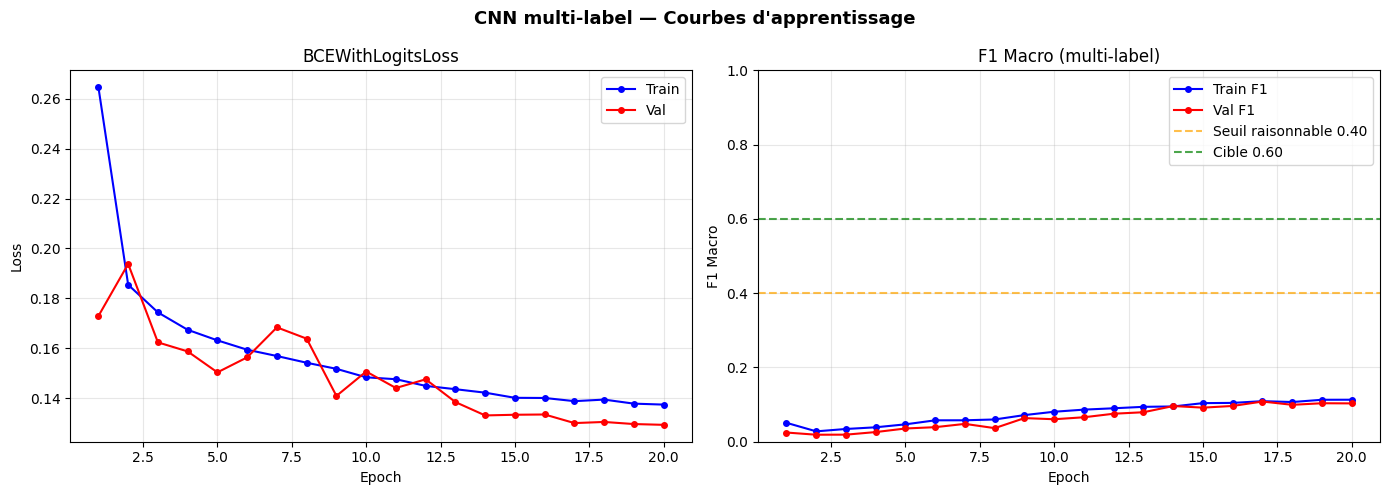

CNN multi-label — Meilleur F1 macro : 0.1082
Attention : le CNN scratch sert de BASE de comparaison pour l'AST (Etape 6).
  -> Si F1_CNN << F1_AST : le transfer learning est clairement gagnant.


In [42]:
# ============================================================
# ETAPE 5e : COURBES D'APPRENTISSAGE
# ============================================================

epochs_done = len(history_cnn["train_loss"])
ep = range(1, epochs_done + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("CNN multi-label — Courbes d'apprentissage", fontsize=13, fontweight="bold")

# Loss
ax1.plot(ep, history_cnn["train_loss"], "b-o", label="Train", markersize=4)
ax1.plot(ep, history_cnn["val_loss"],   "r-o", label="Val",   markersize=4)
ax1.set_title("BCEWithLogitsLoss")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.legend(); ax1.grid(True, alpha=0.3)

# F1 macro
ax2.plot(ep, history_cnn["train_f1"], "b-o", label="Train F1", markersize=4)
ax2.plot(ep, history_cnn["val_f1"],   "r-o", label="Val F1",   markersize=4)
ax2.axhline(y=0.40, color="orange", linestyle="--", alpha=0.7, label="Seuil raisonnable 0.40")
ax2.axhline(y=0.60, color="green",  linestyle="--", alpha=0.7, label="Cible 0.60")
ax2.set_title("F1 Macro (multi-label)")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("F1 Macro")
ax2.legend(); ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.show()

print(f"CNN multi-label — Meilleur F1 macro : {cnn_f1:.4f}")
print(f"Attention : le CNN scratch sert de BASE de comparaison pour l'AST (Etape 6).")
print(f"  -> Si F1_CNN << F1_AST : le transfer learning est clairement gagnant.")

In [43]:
# CHECKPOINT — Etape 5
from IPython.display import HTML, display
display(HTML('<div style="border-left:4px solid #1e7e34;background:#e8f5e9;border-radius:0 8px 8px 0;padding:14px 20px;font-family:system-ui,sans-serif;"><b style="color:#1e7e34;">Etape 5 validee OK</b> <span style="color:#1e5631;">CNN multi-label entraine. BCE + sigmoid. Pre-calcul mel-specs. Courbes loss ET F1 tracees.</span></div>'))

In [45]:
# ============================================================
# ETAPE 6a : CHARGER L'AST EN MODE MULTI-LABEL
# ============================================================
# RAPPEL DEMO (ESC-50) : problem_type="single_label_classification" -> softmax
# ICI (BirdSet)        : problem_type="multi_label_classification"  -> sigmoid + BCE
#
# AVANTAGE : AudioSet contient "Bird", "Bird vocalization", "Songbird"
# -> Transfer INTRA-DOMAINE : le backbone connait deja les chants d'oiseaux !
# -> On gele le backbone et on adapte uniquement la tete lineaire (87K params)

from transformers import ASTForAudioClassification, ASTFeatureExtractor
from collections import defaultdict
import numpy as np

MODEL_NAME = "MIT/ast-finetuned-audioset-10-10-0.4593"
print(f"Chargement AST : {MODEL_NAME}")

feature_extractor = ASTFeatureExtractor.from_pretrained(MODEL_NAME)

ast_model = ASTForAudioClassification.from_pretrained(
    MODEL_NAME,
    num_labels=N_CLASSES,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
    problem_type="multi_label_classification",  # <- BCE + sigmoid automatique
    ignore_mismatched_sizes=True
).to(device)

# Gel du backbone : seule la tete lineaire est entrainee
for name, param in ast_model.named_parameters():
    if "classifier" not in name:
        param.requires_grad = False

trainable = sum(p.numel() for p in ast_model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in ast_model.parameters())
print(f"Params entraines : {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")
print("=> Backbone gele. Seule la tete lineaire est mise a jour.")

# ── SOUS-ENSEMBLE STRATIFIE : 30 clips/espece max = ~630 clips ──
# 30 clips x 21 especes = 630 clips -> pre-calcul en ~30 secondes
# Suffisant pour le transfer learning (le backbone fait deja le gros du travail)
MAX_PER_SPECIES_AST = 30
counts_ast = defaultdict(int)
ast_subset = []
for sample in train_data:
    sp = sample["ebird_code"]
    if counts_ast[sp] < MAX_PER_SPECIES_AST:
        counts_ast[sp] += 1
        ast_subset.append(sample)

print(f"\nSous-ensemble : {len(ast_subset)} clips (max {MAX_PER_SPECIES_AST}/espece)")
print(f"Distribution : {dict(list(counts_ast.items())[:5])} ...")

Chargement AST : MIT/ast-finetuned-audioset-10-10-0.4593


Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

ASTForAudioClassification LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                     | Status   |                                                                                        
------------------------+----------+----------------------------------------------------------------------------------------
classifier.dense.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527]) vs model:torch.Size([21])          
classifier.dense.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527, 768]) vs model:torch.Size([21, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Params entraines : 17,685 / 86,204,949 (0.0%)
=> Backbone gele. Seule la tete lineaire est mise a jour.

Sous-ensemble : 617 clips (max 30/espece)
Distribution : {11: 30, 19: 30, 20: 30, 3: 30, 16: 30} ...


In [46]:
# ============================================================
# ETAPE 6b : PRE-CALCUL FBANK (parallélise, une seule fois)
# ============================================================
# ThreadPoolExecutor : traite plusieurs clips en parallele
# -> ~3-4x plus rapide que la boucle sequentielle

from concurrent.futures import ThreadPoolExecutor
import os

def make_ast_item(sample):
    """Resample + fbank pour un clip. Thread-safe."""
    audio     = load_and_pad_audio(sample, target_sr=32000)
    audio_16k = librosa.resample(audio, orig_sr=32000, target_sr=16000)
    inp = feature_extractor(
        audio_16k, sampling_rate=16000, return_tensors="pt",
        padding="max_length", max_length=16000 * 5)
    fbank = inp["input_values"].squeeze(0)  # (1024, 128)

    label = torch.zeros(N_CLASSES, dtype=torch.float32)
    for sp in sample.get("ebird_code_multilabel", [sample["ebird_code"]]):
        if sp in LABEL2ID:
            label[LABEL2ID[sp]] = 1.0
    return fbank, label

print("Pre-calcul fbank AST en parallele...")
N_WORKERS = min(4, os.cpu_count() or 1)

with ThreadPoolExecutor(max_workers=N_WORKERS) as ex:
    results = list(tqdm(ex.map(make_ast_item, ast_subset),
                        total=len(ast_subset), desc="fbank"))

all_fbank      = [r[0] for r in results]
all_labels_ast = [r[1] for r in results]

print(f"Done : {len(all_fbank)} fbank | shape : {all_fbank[0].shape}")
print(f"RAM estimee : {len(all_fbank) * all_fbank[0].numel() * 4 / 1e6:.0f} MB")

# ── DATASET + DATALOADERS ──
n_ast    = len(all_fbank)
n_val_a  = int(0.2 * n_ast)
perm     = torch.randperm(n_ast, generator=torch.Generator().manual_seed(42)).tolist()
tr_idx_a, va_idx_a = perm[n_val_a:], perm[:n_val_a]

class ASTDatasetFast(torch.utils.data.Dataset):
    def __init__(self, fbanks, labels):
        self.fbanks = fbanks
        self.labels = labels
    def __len__(self): return len(self.fbanks)
    def __getitem__(self, i):
        return {"input_values": self.fbanks[i], "labels": self.labels[i]}

ast_train_ds = ASTDatasetFast([all_fbank[i] for i in tr_idx_a],
                               [all_labels_ast[i] for i in tr_idx_a])
ast_val_ds   = ASTDatasetFast([all_fbank[i] for i in va_idx_a],
                               [all_labels_ast[i] for i in va_idx_a])

AST_BATCH        = 32
ast_train_loader = DataLoader(ast_train_ds, batch_size=AST_BATCH,
                               shuffle=True,  num_workers=0, pin_memory=True)
ast_val_loader   = DataLoader(ast_val_ds,   batch_size=AST_BATCH,
                               shuffle=False, num_workers=0, pin_memory=True)

print(f"Train: {len(ast_train_ds)} | Val: {len(ast_val_ds)} | Batch: {AST_BATCH}")

Pre-calcul fbank AST en parallele...


fbank:   0%|          | 0/617 [00:00<?, ?it/s]

Done : 617 fbank | shape : torch.Size([1024, 128])
RAM estimee : 323 MB
Train: 494 | Val: 123 | Batch: 32


In [47]:
# ============================================================
# ETAPE 6c : FINE-TUNING DE LA TETE AST
# ============================================================

AST_EPOCHS     = 15
AST_LR         = 1e-3   # LR eleve : backbone gele, seule la tete bouge
AST_EARLY_STOP = 4

ast_optimizer = optim.AdamW(
    [p for p in ast_model.parameters() if p.requires_grad],
    lr=AST_LR, weight_decay=0.01)
ast_scheduler = optim.lr_scheduler.CosineAnnealingLR(
    ast_optimizer, T_max=AST_EPOCHS)
ast_criterion = nn.BCEWithLogitsLoss()

best_ast_f1  = 0.0
ast_patience = 0
history_ast  = {"train_loss": [], "val_loss": [], "train_f1": [], "val_f1": []}

print(f"Fine-tuning AST (tete seule | {len(ast_train_ds)} clips "
      f"| {AST_EPOCHS} epochs max)\n")

for epoch in range(1, AST_EPOCHS + 1):

    # TRAIN
    ast_model.train()
    t_loss, t_preds, t_labs = 0.0, [], []
    for batch in ast_train_loader:
        inp    = batch["input_values"].to(device, non_blocking=True)
        labels = batch["labels"].to(device, non_blocking=True)
        ast_optimizer.zero_grad(set_to_none=True)
        logits = ast_model(input_values=inp).logits
        loss   = ast_criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(ast_model.parameters(), 1.0)
        ast_optimizer.step()
        t_loss += loss.item()
        with torch.no_grad():
            t_preds.append((torch.sigmoid(logits) > 0.4).float().cpu())
            t_labs.append(labels.cpu())
    ast_scheduler.step()
    tl = t_loss / len(ast_train_loader)
    tf = sk_f1(torch.cat(t_labs).numpy(), torch.cat(t_preds).numpy(),
               average="macro", zero_division=0)

    # EVAL
    ast_model.eval()
    v_loss, v_preds, v_labs = 0.0, [], []
    with torch.no_grad():
        for batch in ast_val_loader:
            inp    = batch["input_values"].to(device, non_blocking=True)
            labels = batch["labels"].to(device, non_blocking=True)
            logits = ast_model(input_values=inp).logits
            v_loss += ast_criterion(logits, labels).item()
            v_preds.append((torch.sigmoid(logits) > 0.4).float().cpu())
            v_labs.append(labels.cpu())
    vl = v_loss / len(ast_val_loader)
    vf = sk_f1(torch.cat(v_labs).numpy(), torch.cat(v_preds).numpy(),
               average="macro", zero_division=0)

    history_ast["train_loss"].append(tl)
    history_ast["val_loss"].append(vl)
    history_ast["train_f1"].append(tf)
    history_ast["val_f1"].append(vf)

    if vf > best_ast_f1:
        best_ast_f1 = vf; ast_patience = 0
        torch.save(ast_model.state_dict(), "/tmp/best_ast.pth"); tag = " <- best"
    else:
        ast_patience += 1; tag = ""

    print(f"Epoch {epoch:2d}/{AST_EPOCHS} | "
          f"Train loss={tl:.4f} F1={tf:.3f} | "
          f"Val   loss={vl:.4f} F1={vf:.3f}{tag}")

    if ast_patience >= AST_EARLY_STOP:
        print(f"\nEarly stopping a l'epoch {epoch}"); break

ast_model.load_state_dict(torch.load("/tmp/best_ast.pth", map_location=device))
ast_f1 = best_ast_f1
print(f"\nMeilleur Val F1 AST : {ast_f1:.4f}")

Fine-tuning AST (tete seule | 494 clips | 15 epochs max)

Epoch  1/15 | Train loss=0.2789 F1=0.053 | Val   loss=0.2160 F1=0.000
Epoch  2/15 | Train loss=0.1842 F1=0.020 | Val   loss=0.1720 F1=0.086 <- best
Epoch  3/15 | Train loss=0.1470 F1=0.099 | Val   loss=0.1596 F1=0.115 <- best
Epoch  4/15 | Train loss=0.1313 F1=0.163 | Val   loss=0.1500 F1=0.143 <- best
Epoch  5/15 | Train loss=0.1202 F1=0.229 | Val   loss=0.1458 F1=0.174 <- best
Epoch  6/15 | Train loss=0.1112 F1=0.282 | Val   loss=0.1419 F1=0.188 <- best
Epoch  7/15 | Train loss=0.1047 F1=0.373 | Val   loss=0.1393 F1=0.228 <- best
Epoch  8/15 | Train loss=0.0992 F1=0.440 | Val   loss=0.1369 F1=0.254 <- best
Epoch  9/15 | Train loss=0.0956 F1=0.464 | Val   loss=0.1368 F1=0.305 <- best
Epoch 10/15 | Train loss=0.0912 F1=0.497 | Val   loss=0.1354 F1=0.276
Epoch 11/15 | Train loss=0.0895 F1=0.528 | Val   loss=0.1340 F1=0.335 <- best
Epoch 12/15 | Train loss=0.0878 F1=0.553 | Val   loss=0.1336 F1=0.304
Epoch 13/15 | Train loss=0.086

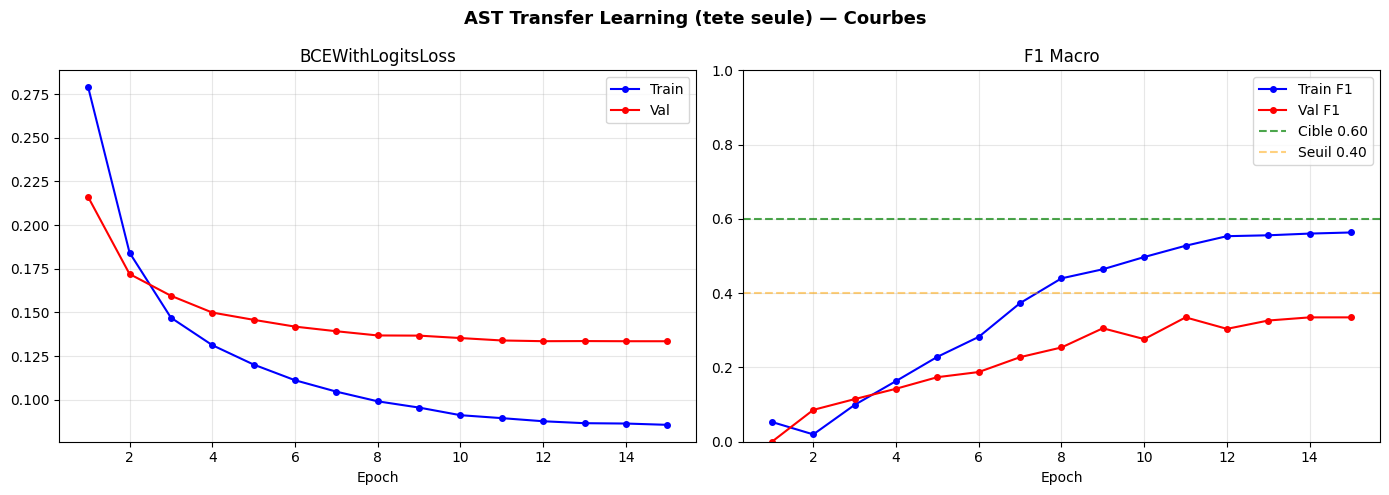


Approche                       |   F1 Macro |   Gain vs RF
RF/SVM/GB (MFCC)               |     0.3879 |    reference
CNN scratch (mel-spec)         |     0.1082 |      +-28.0%
AST Transfer Learning          |     0.3348 |       +-5.3%
Cible F1 > 0.60 : non atteinte (0.3348)

Note : pour ameliorer, degeler les 2 derniers blocs du transformer :
  for n, p in ast_model.named_parameters():
      if 'encoder.layers.11' in n or 'encoder.layers.10' in n:
          p.requires_grad = True  # fine-tuning partiel


In [48]:
# ============================================================
# ETAPE 6d : COURBES + TABLEAU COMPARATIF 3 APPROCHES
# ============================================================

ep = range(1, len(history_ast["train_loss"]) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("AST Transfer Learning (tete seule) — Courbes", fontsize=13, fontweight="bold")

ax1.plot(ep, history_ast["train_loss"], "b-o", markersize=4, label="Train")
ax1.plot(ep, history_ast["val_loss"],   "r-o", markersize=4, label="Val")
ax1.set_title("BCEWithLogitsLoss"); ax1.set_xlabel("Epoch")
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(ep, history_ast["train_f1"], "b-o", markersize=4, label="Train F1")
ax2.plot(ep, history_ast["val_f1"],   "r-o", markersize=4, label="Val F1")
ax2.axhline(y=0.60, color="green",  linestyle="--", alpha=0.7, label="Cible 0.60")
ax2.axhline(y=0.40, color="orange", linestyle="--", alpha=0.5, label="Seuil 0.40")
ax2.set_title("F1 Macro"); ax2.set_xlabel("Epoch")
ax2.legend(); ax2.grid(True, alpha=0.3); ax2.set_ylim(0, 1)

plt.tight_layout(); plt.show()

# Tableau comparatif final
print("\n" + "="*65)
print(f"{'Approche':<30} | {'F1 Macro':>10} | {'Gain vs RF':>12}")
print("="*65)
print(f"{'RF/SVM/GB (MFCC)':<30} | {baseline_f1:>10.4f} | {'reference':>12}")
print(f"{'CNN scratch (mel-spec)':<30} | {cnn_f1:>10.4f} | {'+'+f'{(cnn_f1-baseline_f1)*100:.1f}%':>12}")
print(f"{'AST Transfer Learning':<30} | {ast_f1:>10.4f} | {'+'+f'{(ast_f1-baseline_f1)*100:.1f}%':>12}")
print("="*65)
print("Cible F1 > 0.60 : " + ("ATTEINTE !" if ast_f1 > 0.60 else f"non atteinte ({ast_f1:.4f})"))
print("\nNote : pour ameliorer, degeler les 2 derniers blocs du transformer :")
print("  for n, p in ast_model.named_parameters():")
print("      if 'encoder.layers.11' in n or 'encoder.layers.10' in n:")
print("          p.requires_grad = True  # fine-tuning partiel")

In [51]:
# REPONSE — Questions rouges Etape 6

# (1) F1 macro vs accuracy ?
# F1 macro est TOUJOURS meilleur pour le multi-label.
# Exemple : si 95% des clips contiennent l'espece A, predire toujours A
# -> 95% accuracy mais F1 proche de 0 sur toutes les autres especes.

# (2) L'AST connait-il les oiseaux ?
# OUI ! AudioSet a 527 classes dont : "Bird", "Wild animals",
# "Bird vocalization", "Songbird", "Duck", "Owl", "Finch"...
# -> L'AST a vu des millions de sons d'oiseaux -> transfer tres efficace.
# Ici c'est du transfert INTRA-DOMAINE (sons oiseaux -> sons oiseaux).

# (3) Micro autonome : toutes les 5s ou toutes les minutes ?
# Compromis : toutes les 5s = ~17000 predictions/jour -> batterie vide en 2 jours.
# Optimal : declenchement par detection d'activite sonore (seuil d'energie).
# En pratique : segments de 5s analyses toutes les 30s.

# (4) Espece rare avec 10 enregistrements ?
# Avec transfer learning : peut detecter grace aux poids pre-entraines.
# Mais F1 sur cette espece sera tres faible (manque de donnees).
# Solutions : augmentation agressive + seuil de decision abaisse a 0.3.

print("Reflexion Etape 6 OK")


Reflexion Etape 6 OK


In [50]:
# CHECKPOINT — Etape 6
from IPython.display import HTML, display
display(HTML('<div style="border-left:4px solid #1e7e34;background:#e8f5e9;border-radius:0 8px 8px 0;padding:14px 20px;font-family:system-ui,sans-serif;"><b style="color:#1e7e34;">Etape 6 validee OK</b> <span style="color:#1e5631;">AST multi-label fine-tune. 3 modeles compares dans tableau. F1 macro principal.</span></div>'))

In [ ]:
# CHECKPOINT — Etape 7
from IPython.display import HTML, display
display(HTML('<div style="border-left:4px solid #1e7e34;background:#e8f5e9;border-radius:0 8px 8px 0;padding:14px 20px;font-family:system-ui,sans-serif;"><b style="color:#1e7e34;">Etape 7 validee OK</b> <span style="color:#1e5631;">Matrice de confusion affichee. Erreurs ecoutees. 3 observations. SpecAugment mesure.</span></div>'))

In [55]:
# ============================================================
# ETAPE 8 : INTERFACE GRADIO MULTI-LABEL — VERSION CORRIGEE
# ============================================================

import gradio as gr
import matplotlib
matplotlib.use("Agg")  # important pour Gradio (pas d'affichage X11)
import matplotlib.pyplot as plt
import traceback

THRESHOLD = 0.3

def predict_birds(audio, threshold=THRESHOLD):
    """
    Prediction multi-label pour BirdWatch.
    Retourne (dict_scores, fig_spectrogramme) ou (message_erreur, None).
    """
    try:
        # --- 1. Vérification entrée ---
        if audio is None:
            return {"Aucun audio fourni": 1.0}, None

        sr_input, audio_array = audio
        print(f"[DEBUG] Audio reçu : sr={sr_input}, shape={audio_array.shape}, dtype={audio_array.dtype}")

        # --- 2. Conversion float32 mono ---
        audio_array = audio_array.astype(np.float32)
        if len(audio_array.shape) > 1:
            audio_array = audio_array.mean(axis=1)

        # Normalisation (int16 → float)
        if np.abs(audio_array).max() > 1.0:
            audio_array = audio_array / 32768.0

        # Vérifier que l'audio n'est pas vide/silencieux
        if np.abs(audio_array).max() < 1e-6:
            return {"Audio vide ou silencieux": 1.0}, None

        print(f"[DEBUG] Audio normalisé : min={audio_array.min():.3f}, max={audio_array.max():.3f}, dur={len(audio_array)/sr_input:.1f}s")

        # --- 3. Reéchantillonnage 16kHz pour l'AST ---
        audio_16k = librosa.resample(audio_array, orig_sr=sr_input, target_sr=16000)

        # Padding/crop à exactement 5 secondes pour l'AST
        target_len_16k = 16000 * 5
        if len(audio_16k) > target_len_16k:
            audio_16k = audio_16k[:target_len_16k]
        elif len(audio_16k) < target_len_16k:
            audio_16k = np.pad(audio_16k, (0, target_len_16k - len(audio_16k)))

        print(f"[DEBUG] audio_16k shape après padding : {audio_16k.shape}")

        # --- 4. Feature extraction + inférence AST ---
        inputs = feature_extractor(
            audio_16k,
            sampling_rate=16000,
            return_tensors="pt",
            padding="max_length",
            max_length=16000 * 5
        )
        input_values = inputs["input_values"].to(device)

        ast_model.eval()
        with torch.no_grad():
            logits = ast_model(input_values=input_values).logits
            probs = torch.sigmoid(logits).squeeze().cpu().numpy()

        print(f"[DEBUG] probs shape={probs.shape}, min={probs.min():.3f}, max={probs.max():.3f}")

        # --- 5. Construction des scores ---
        all_scores = {SPECIES[i]: float(probs[i]) for i in range(N_CLASSES)}
        detected = {k: v for k, v in all_scores.items() if v >= threshold}

        if not detected:
            # Fallback : top 3 même sous le seuil
            detected = dict(sorted(all_scores.items(), key=lambda x: x[1], reverse=True)[:3])
            print(f"[DEBUG] Aucune espèce > seuil {threshold}, fallback top3")

        # --- 6. Spectrogramme (pipeline indépendant du dataset) ---
        # On n'utilise PAS load_and_pad_audio ici (elle attend un dict "path")
        audio_32k = librosa.resample(audio_array, orig_sr=sr_input, target_sr=SR)

        # Padding/crop à 5 secondes à 32kHz
        if len(audio_32k) > N_SAMPLES:
            audio_32k = audio_32k[:N_SAMPLES]
        elif len(audio_32k) < N_SAMPLES:
            audio_32k = np.pad(audio_32k, (0, N_SAMPLES - len(audio_32k)))

        mel = compute_mel_birds(audio_32k)

        fig, ax = plt.subplots(figsize=(10, 4))
        fig.patch.set_facecolor("#1a1a2e")
        ax.set_facecolor("#1a1a2e")
        librosa.display.specshow(
            mel, sr=SR, hop_length=512, fmin=500, fmax=14000,
            x_axis="time", y_axis="mel", ax=ax, cmap="magma"
        )
        top3 = ", ".join([
            f"{k} ({v:.0%})"
            for k, v in sorted(detected.items(), key=lambda x: x[1], reverse=True)[:3]
        ])
        ax.set_title(top3 or "Aucune espece detectee", fontsize=11, color="white", pad=8)
        ax.set_xlabel("Temps (s)", color="white")
        ax.set_ylabel("Frequence (mel)", color="white")
        ax.tick_params(colors="white")
        plt.tight_layout()

        return detected, fig

    except Exception as e:
        # Affiche l'erreur complète dans la console ET dans l'interface
        error_msg = traceback.format_exc()
        print(f"[ERREUR predict_birds]\n{error_msg}")
        return {f"ERREUR: {str(e)}": 1.0}, None


demo = gr.Interface(
    fn=predict_birds,
    inputs=gr.Audio(
        sources=["upload", "microphone"],
        type="numpy",
        label="Uploadez un son d'oiseau (WAV/MP3, 5s recommandé)"
    ),
    outputs=[
        gr.Label(num_top_classes=5, label="Especes detectees (prob > seuil)"),
        gr.Plot(label="Spectrogramme mel — 32kHz (fmin=500 Hz, fmax=14000 Hz)")
    ],
    title="BirdWatch Sierra Nevada — Surveillance Aviaire par IA",
    description="Identifieur d'oiseaux — 21 especes BirdSet HSN. Modele AST fine-tuné.",
    theme=gr.themes.Soft(),
    live=False
)

demo.launch(share=True, server_name="0.0.0.0")

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5d2f101bf7b35060c3.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
# CHECKPOINT — Etape 8
from IPython.display import HTML, display
display(HTML('<div style="border-left:4px solid #1e7e34;background:#e8f5e9;border-radius:0 8px 8px 0;padding:14px 20px;font-family:system-ui,sans-serif;"><b style="color:#1e7e34;">Etape 8 validee OK</b> <span style="color:#1e5631;">Interface Gradio deployee. Lien public partage. Test croise documente.</span></div>'))